<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/hydrogen/liquefaction_of_hydrogen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Liquefaction of hydrogen with NeqSim

This notebook develops a transparent hydrogen-liquefaction screening workflow using NeqSim,
reference-property checks, and explicit corrections for physics outside a cubic EOS.

**Intended audience.** Process and energy engineers, advanced students, and researchers who need
an executable introduction to hydrogen cooling, condensation, refrigeration, and storage.

**Prerequisites.** Python fundamentals and familiarity with phase equilibrium, enthalpy, entropy,
compressors, expanders, and steady-flow energy balances.

**Learning objectives.** You will learn to:

1. model pure hydrogen with the SRK equation of state and state its limitations;
2. calculate and benchmark the normal boiling point and saturated-liquid density;
3. construct a staged hydrogen cooler in a NeqSim `ProcessSystem`;
4. close mass and enthalpy balances and estimate reversible liquefaction work;
5. add the separately sourced ortho-to-para conversion heat;
6. screen a helium Brayton cold-end and operating sensitivities;
7. estimate tank volume and heat-leak boil-off with defensible engineering checks.


In [1]:
import json
from importlib import metadata, util
import math
import subprocess
import sys

if util.find_spec("neqsim") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "neqsim==3.16.0"]
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim import jneqsim

NEQSIM_VERSION = metadata.version("neqsim")
assert NEQSIM_VERSION == "3.16.0"

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {sys.version.split()[0]}")


NeqSim version: 3.16.0
Python version: 3.12.13


## 1. Design basis, units, and thermodynamic boundary

The base feed is pure hydrogen at 298.15 K and 1.2 bara. A 1,000 kg/h stream is cooled at
constant pressure through 120, 80, 40, 22, and 20 K. The final state is liquid in the SRK model.
Real plants use compressed hydrogen and multilevel nitrogen, hydrogen, helium, or mixed-refrigerant
cycles; the staged cooler represents the hydrogen-side cooling curve, not utility hardware.

For a pure component, the composition condition is simply:

$$
z_{\mathrm{H_2}} = 1
$$

$z_{\mathrm{H_2}}$ is hydrogen mole fraction in mol/mol. SI units are used, with `bara` and
`kg/hr` passed as explicit NeqSim engineering-unit strings.


In [2]:
AMBIENT_TEMPERATURE_K = 298.15
HYDROGEN_PRESSURE_BARA = 1.2
HYDROGEN_FLOW_KG_PER_H = 1_000.0
PRODUCT_TEMPERATURE_K = 20.0
NORMAL_PRESSURE_BARA = 1.01325

REFERENCE_NORMAL_BOILING_K = 20.369
REFERENCE_LIQUID_DENSITY_KG_PER_M3 = 70.85
REFERENCE_LATENT_HEAT_KJ_PER_KG = 446.0
REFERENCE_FULL_ORTHO_PARA_HEAT_KJ_PER_KG = 703.0
INITIAL_ORTHO_FRACTION = 0.75
FINAL_ORTHO_FRACTION = 0.002
HYDROGEN_LHV_KWH_PER_KG = 33.3

HYDROGEN_COMPOSITION = {"hydrogen": 1.0}
composition_sum = sum(HYDROGEN_COMPOSITION.values())

assert np.isclose(composition_sum, 1.0, atol=1.0e-12)

print(f"Hydrogen composition sum [mol/mol]: {composition_sum:.6f}")
print(f"Base hydrogen flow [kg/h]: {HYDROGEN_FLOW_KG_PER_H:.1f}")
print(f"Product pressure [bara]: {HYDROGEN_PRESSURE_BARA:.3f}")


Hydrogen composition sum [mol/mol]: 1.000000
Base hydrogen flow [kg/h]: 1000.0
Product pressure [bara]: 1.200


## 2. How NeqSim represents hydrogen and the process

`SystemSrkEos` stores the hydrogen component, temperature, pressure, phases, and SRK parameters.
`ThermodynamicOperations` performs equilibrium flashes. A named `Stream` adds flow rate, while
`Cooler`, `Compressor`, `Expander`, and `Heater` provide composable unit operations.
`ProcessSystem.run()` executes those units in dependency order.

SRK is selected because it is robust and transparent for engineering screening and connects
directly to NeqSim process equipment. It is not a reference EOS for cryogenic hydrogen. Quantum
effects and separate normal-, ortho-, and parahydrogen formulations require a dedicated model
such as the Leachman reference equations. We therefore benchmark every important cryogenic result
and keep the expected model-form error visible.


In [3]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
Compressor = jneqsim.process.equipment.compressor.Compressor
Expander = jneqsim.process.equipment.expander.Expander
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def make_pure_fluid(component_name, temperature_k, pressure_bara):
    fluid = SystemSrkEos(temperature_k, pressure_bara)
    fluid.addComponent(component_name, 1.0)
    fluid.setMixingRule("classic")
    return fluid


def hydrogen_state(temperature_k, pressure_bara):
    fluid = make_pure_fluid("hydrogen", temperature_k, pressure_bara)
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid


## 3. Critical and triple-point limits

Hydrogen's critical temperature is only about 33 K. Above the critical pressure and temperature,
there is no vapor-liquid boundary, so a condensation temperature is undefined. Below the triple
point near 13.8 K, a vapor-liquid-only model is incomplete because solid hydrogen becomes stable.

The EOS component database supplies $T_c$, $p_c$, and the acentric factor. These are checked before
solving saturation. This notebook stays between the triple and critical limits and below the
critical pressure.


In [4]:
property_fluid = make_pure_fluid("hydrogen", 25.0, NORMAL_PRESSURE_BARA)
hydrogen_component = property_fluid.getPhase(0).getComponent("hydrogen")

critical_temperature_k = hydrogen_component.getTC()
critical_pressure_bara = hydrogen_component.getPC()
acentric_factor = hydrogen_component.getAcentricFactor()
triple_temperature_k = 13.8

assert 33.0 < critical_temperature_k < 33.4
assert 12.8 < critical_pressure_bara < 13.1
assert triple_temperature_k < REFERENCE_NORMAL_BOILING_K < critical_temperature_k

print(f"NeqSim critical temperature [K]: {critical_temperature_k:.4f}")
print(f"NeqSim critical pressure [bara]: {critical_pressure_bara:.4f}")
print(f"NeqSim acentric factor [-]: {acentric_factor:.4f}")
print(f"Reference triple temperature [K]: {triple_temperature_k:.2f}")


NeqSim critical temperature [K]: 33.2000
NeqSim critical pressure [bara]: 12.9700
NeqSim acentric factor [-]: -0.2200
Reference triple temperature [K]: 13.80


## 4. Pure-component saturation from fugacity equality

At vapor-liquid equilibrium for pure hydrogen, liquid and vapor fugacities are equal:

$$
f^{\mathrm{L}}(T,p) = f^{\mathrm{V}}(T,p)
$$

Because both phases contain pure hydrogen, the root function can be written as the logarithm of
the liquid-to-vapor fugacity-coefficient ratio. A bracketed bisection is used because it is
deterministic and cannot jump outside the physical temperature interval.

PyPI NeqSim 3.16.0's general `bubblePointTemperatureFlash()` gives a nonphysical result for pure
hydrogen. This notebook uses the same public EOS fugacity API with a bounded pure-component root;
a separate NeqSim regression fix is submitted with this tutorial.


In [5]:
def pure_hydrogen_fugacity_residual(fluid, temperature_k):
    fluid.setTemperature(temperature_k)
    fluid.setNumberOfPhases(2)

    for phase_index in (0, 1):
        component = fluid.getPhase(phase_index).getComponent("hydrogen")
        component.setx(1.0)

    fluid.init(3)
    vapor_coefficient = (
        fluid.getPhase(0).getComponent("hydrogen").getFugacityCoefficient()
    )
    liquid_coefficient = (
        fluid.getPhase(1).getComponent("hydrogen").getFugacityCoefficient()
    )
    return math.log(liquid_coefficient / vapor_coefficient)


def hydrogen_saturation_temperature(pressure_bara):
    if not 0.0 < pressure_bara < critical_pressure_bara:
        raise ValueError("Pressure must be positive and below hydrogen critical pressure.")

    fluid = make_pure_fluid("hydrogen", 20.0, pressure_bara)
    wilson_estimate_k = critical_temperature_k / (
        1.0
        - math.log(pressure_bara / critical_pressure_bara)
        / (5.373 * (1.0 + acentric_factor))
    )
    lower_temperature_k = max(triple_temperature_k + 0.01, 0.70 * wilson_estimate_k)
    upper_temperature_k = min(
        critical_temperature_k * (1.0 - 1.0e-7),
        1.30 * wilson_estimate_k,
    )
    lower_residual = pure_hydrogen_fugacity_residual(
        fluid,
        lower_temperature_k,
    )
    upper_residual = pure_hydrogen_fugacity_residual(
        fluid,
        upper_temperature_k,
    )

    if lower_residual * upper_residual > 0.0:
        raise RuntimeError("The SRK vapor-liquid root was not bracketed.")

    for _ in range(100):
        midpoint_k = 0.5 * (lower_temperature_k + upper_temperature_k)
        midpoint_residual = pure_hydrogen_fugacity_residual(fluid, midpoint_k)

        if abs(midpoint_residual) < 1.0e-10:
            return midpoint_k

        if lower_residual * midpoint_residual <= 0.0:
            upper_temperature_k = midpoint_k
            upper_residual = midpoint_residual
        else:
            lower_temperature_k = midpoint_k
            lower_residual = midpoint_residual

    raise RuntimeError("Hydrogen saturation solve did not converge.")


srk_normal_boiling_k = hydrogen_saturation_temperature(NORMAL_PRESSURE_BARA)
boiling_point_error_k = srk_normal_boiling_k - REFERENCE_NORMAL_BOILING_K

assert abs(boiling_point_error_k) < 1.0

print(f"SRK normal boiling temperature [K]: {srk_normal_boiling_k:.6f}")
print(f"Reference normal boiling temperature [K]: {REFERENCE_NORMAL_BOILING_K:.6f}")
print(f"SRK minus reference [K]: {boiling_point_error_k:.6f}")


SRK normal boiling temperature [K]: 20.541408
Reference normal boiling temperature [K]: 20.369000
SRK minus reference [K]: 0.172408


## 5. Saturation-pressure sensitivity

Storage pressure raises the saturation temperature until the vapor-liquid boundary terminates at
the critical point. This can ease refrigeration temperature but increases vessel pressure and
changes density, boil-off handling, and safety design.

The sensitivity stops at 10 bara, below the 12.97 bara SRK critical pressure. It must not be
extrapolated through the critical point or below the triple point.


In [6]:
saturation_pressures_bara = np.array(
    [1.01325, 1.2, 2.0, 4.0, 6.0, 8.0, 10.0]
)
saturation_temperatures_k = np.array(
    [
        hydrogen_saturation_temperature(float(pressure_bara))
        for pressure_bara in saturation_pressures_bara
    ]
)
saturation_table = pd.DataFrame(
    {
        "pressure [bara]": saturation_pressures_bara,
        "SRK saturation temperature [K]": saturation_temperatures_k,
    }
)

assert np.all(np.diff(saturation_temperatures_k) > 0.0)
assert np.all(saturation_temperatures_k < critical_temperature_k)

print(saturation_table.to_string(index=False))


 pressure [bara]  SRK saturation temperature [K]
         1.01325                       20.541408
         1.20000                       21.096260
         2.00000                       22.956476
         4.00000                       26.017239
         6.00000                       28.165497
         8.00000                       29.883998
        10.00000                       31.343443


## 6. Visual check of the phase boundary

A smooth, monotonic saturation curve is a useful diagnostic for the root solver. The curve becomes
steeper as the critical point is approached. The plot is an SRK screening result; for property
guarantees, use a validated normal- or parahydrogen reference EOS.


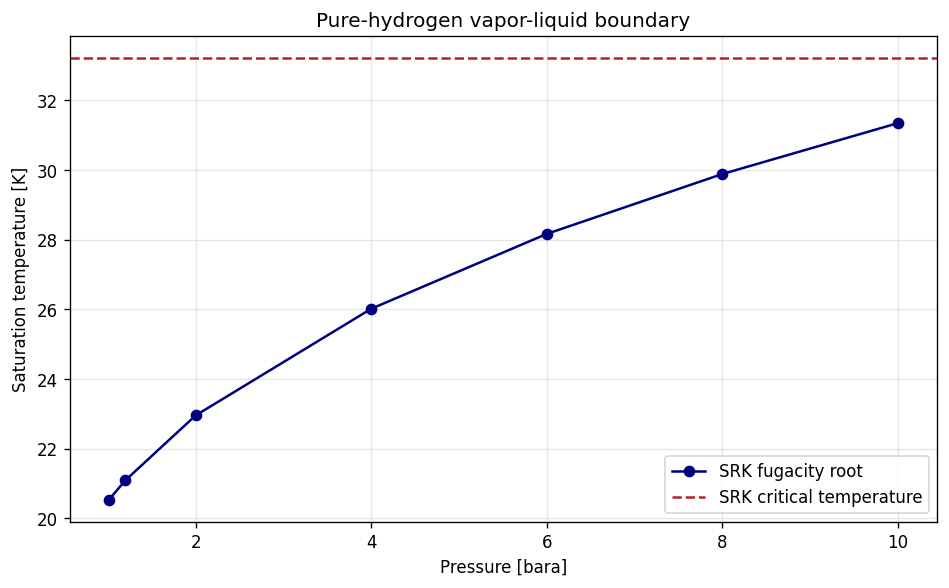

In [7]:
saturation_figure, saturation_axis = plt.subplots(figsize=(8.0, 5.0))

saturation_axis.plot(
    saturation_pressures_bara,
    saturation_temperatures_k,
    color="navy",
    marker="o",
    label="SRK fugacity root",
)
saturation_axis.axhline(
    critical_temperature_k,
    color="firebrick",
    linestyle="--",
    label="SRK critical temperature",
)
saturation_axis.set_xlabel("Pressure [bara]")
saturation_axis.set_ylabel("Saturation temperature [K]")
saturation_axis.set_title("Pure-hydrogen vapor-liquid boundary")
saturation_axis.grid(alpha=0.3)
saturation_axis.legend()
saturation_figure.tight_layout()
plt.show()


## 7. Hydrogen cooling states

A TP flash is evaluated from ambient temperature to 20 K at 1.2 bara. The phase change occurs
between 22 and 20 K, consistent with the calculated 21.10 K saturation temperature at 1.2 bara.

Specific enthalpy and entropy use NeqSim reference states. Absolute values depend on the reference,
but differences are consistent within one model and enter energy and exergy balances.


In [8]:
cooling_temperatures_k = np.array(
    [298.15, 240.0, 180.0, 120.0, 80.0, 60.0, 40.0, 30.0, 22.0, 20.0]
)
state_records = []

for temperature_k in cooling_temperatures_k:
    state = hydrogen_state(float(temperature_k), HYDROGEN_PRESSURE_BARA)
    phase_names = [
        str(state.getPhase(index).getPhaseTypeName())
        for index in range(state.getNumberOfPhases())
    ]
    state_records.append(
        {
            "temperature [K]": temperature_k,
            "enthalpy [kJ/kg]": state.getEnthalpy("J/kg") / 1_000.0,
            "entropy [kJ/(kg K)]": state.getEntropy("J/kgK") / 1_000.0,
            "density [kg/m3]": state.getDensity("kg/m3"),
            "phase": ", ".join(phase_names),
        }
    )

state_table = pd.DataFrame(state_records)
enthalpy_differences = np.diff(state_table["enthalpy [kJ/kg]"].to_numpy())

assert np.all(enthalpy_differences < 0.0)
assert state_table.iloc[0]["phase"] == "gas"
assert state_table.iloc[-1]["phase"] == "oil"

print(state_table.to_string(index=False))


 temperature [K]  enthalpy [kJ/kg]  entropy [kJ/(kg K)]  density [kg/m3] phase
          298.15        355.977827             0.546717         0.097523   gas
          240.00       -468.362940            -2.528104         0.121147   gas
          180.00      -1303.684785            -6.531084         0.161540   gas
          120.00      -2116.844059           -12.020295         0.242468   gas
           80.00      -2643.009071           -17.349033         0.364545   gas
           60.00      -2900.787429           -21.055762         0.488015   gas
           40.00      -3155.735735           -26.223171         0.741970   gas
           30.00      -3283.325745           -29.894505         1.011026   gas
           22.00      -3387.573234           -33.940091         1.449864   gas
           20.00      -3901.578096           -58.317915        75.483070   oil


## 8. Cooling curve and the condensation step

For a steady cooler with no shaft work and negligible kinetic and potential-energy changes:

$$
\dot Q_{\mathrm{removed}} = \dot m (h_{\mathrm{in}} - h_{\mathrm{out}})
$$

$\dot Q_{\mathrm{removed}}$ is removed heat in W, $\dot m$ is mass flow in kg/s, and $h$ is
specific enthalpy in J/kg. The sharp final enthalpy change includes the SRK latent heat. It is
checked separately against the 446 kJ/kg reference value.


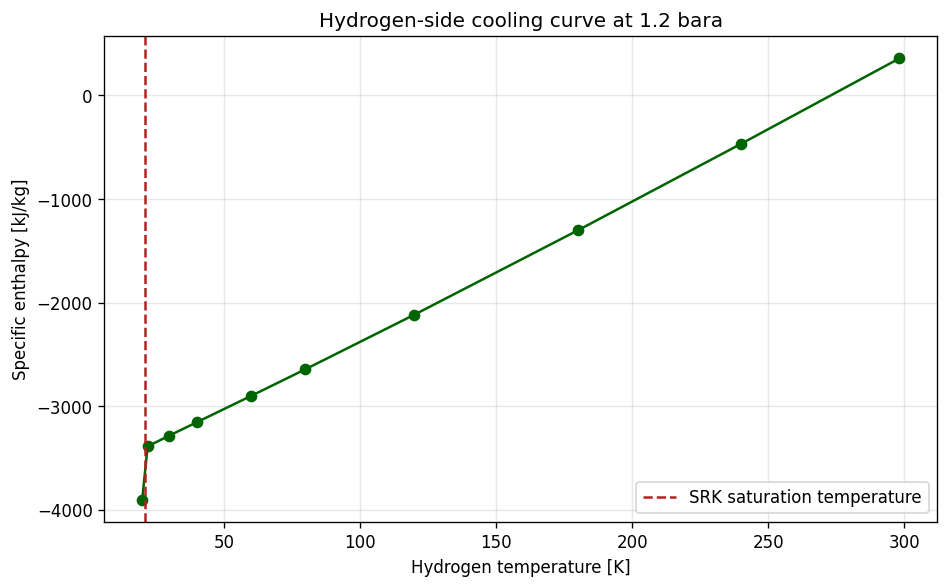

In [9]:
cooling_figure, cooling_axis = plt.subplots(figsize=(8.0, 5.0))

cooling_axis.plot(
    state_table["temperature [K]"],
    state_table["enthalpy [kJ/kg]"],
    color="darkgreen",
    marker="o",
)
cooling_axis.axvline(
    hydrogen_saturation_temperature(HYDROGEN_PRESSURE_BARA),
    color="firebrick",
    linestyle="--",
    label="SRK saturation temperature",
)
cooling_axis.set_xlabel("Hydrogen temperature [K]")
cooling_axis.set_ylabel("Specific enthalpy [kJ/kg]")
cooling_axis.set_title("Hydrogen-side cooling curve at 1.2 bara")
cooling_axis.grid(alpha=0.3)
cooling_axis.legend()
cooling_figure.tight_layout()
plt.show()


## 9. Staged hydrogen-side process model

Five named `Cooler` blocks represent successive temperature intervals: ambient cooling,
nitrogen-range precooling, deep cryogenic cooling, approach to saturation, and condensation.
They expose intermediate states and duties for validation.

The blocks do not imply that cooling water or liquid nitrogen can reach every target. A real
plant maps these intervals to multistream exchangers and closed refrigerant cycles while enforcing
minimum temperature approaches and pressure losses.


In [10]:
hydrogen_feed = Stream(
    "hydrogen feed",
    make_pure_fluid(
        "hydrogen",
        AMBIENT_TEMPERATURE_K,
        HYDROGEN_PRESSURE_BARA,
    ),
)
hydrogen_feed.setFlowRate(HYDROGEN_FLOW_KG_PER_H, "kg/hr")
hydrogen_feed.setTemperature(AMBIENT_TEMPERATURE_K, "K")
hydrogen_feed.setPressure(HYDROGEN_PRESSURE_BARA, "bara")

cooling_targets_k = [120.0, 80.0, 40.0, 22.0, PRODUCT_TEMPERATURE_K]
cooler_names = [
    "ambient precooler",
    "nitrogen-range precooler",
    "deep cryogenic cooler",
    "saturation approach cooler",
    "hydrogen condenser",
]
hydrogen_process = ProcessSystem()
hydrogen_process.add(hydrogen_feed)
hydrogen_coolers = []
upstream_stream = hydrogen_feed

for cooler_name, target_temperature_k in zip(cooler_names, cooling_targets_k):
    cooler = Cooler(cooler_name, upstream_stream)
    cooler.setOutTemperature(target_temperature_k)
    hydrogen_process.add(cooler)
    hydrogen_coolers.append(cooler)
    upstream_stream = cooler.getOutletStream()

hydrogen_process.run()
liquid_hydrogen_stream = hydrogen_coolers[-1].getOutletStream()

stage_table = pd.DataFrame(
    {
        "stage": cooler_names,
        "outlet temperature [K]": [
            cooler.getOutletStream().getTemperature("K")
            for cooler in hydrogen_coolers
        ],
        "removed duty [kW]": [
            abs(cooler.getDuty()) / 1_000.0
            for cooler in hydrogen_coolers
        ],
    }
)

print(stage_table.to_string(index=False))


                     stage  outlet temperature [K]  removed duty [kW]
         ambient precooler                   120.0         686.894968
  nitrogen-range precooler                    80.0         146.156948
     deep cryogenic cooler                    40.0         142.424073
saturation approach cooler                    22.0          64.399305
        hydrogen condenser                    20.0         142.779128


## 10. Duty, mass balance, and latent-heat benchmark

The sum of cooler duties must match the feed-to-product enthalpy-rate difference. The feed and
product mass rates must also be identical because no material leaves the cooler train.

The final 22-to-20 K stage crosses saturation and provides an approximate latent-plus-sensible
duty. Comparing it with a 446 kJ/kg reference latent heat exposes the expected error of a generic
cubic EOS near liquid-hydrogen conditions.


In [11]:
feed_mass_rate_kg_per_s = hydrogen_feed.getFlowRate("kg/sec")
product_mass_rate_kg_per_s = liquid_hydrogen_stream.getFlowRate("kg/sec")
feed_enthalpy_j_per_kg = hydrogen_feed.getFluid().getEnthalpy("J/kg")
product_enthalpy_j_per_kg = liquid_hydrogen_stream.getFluid().getEnthalpy("J/kg")

overall_duty_w = feed_mass_rate_kg_per_s * (
    feed_enthalpy_j_per_kg - product_enthalpy_j_per_kg
)
summed_duty_w = sum(abs(cooler.getDuty()) for cooler in hydrogen_coolers)
duty_relative_error = abs(overall_duty_w - summed_duty_w) / overall_duty_w
mass_relative_error = abs(
    feed_mass_rate_kg_per_s - product_mass_rate_kg_per_s
) / feed_mass_rate_kg_per_s
srk_condensing_stage_kj_per_kg = (
    abs(hydrogen_coolers[-1].getDuty()) / feed_mass_rate_kg_per_s / 1_000.0
)
latent_heat_relative_error = abs(
    srk_condensing_stage_kj_per_kg - REFERENCE_LATENT_HEAT_KJ_PER_KG
) / REFERENCE_LATENT_HEAT_KJ_PER_KG

assert duty_relative_error < 1.0e-9
assert mass_relative_error < 1.0e-12
assert latent_heat_relative_error < 0.20

print(f"Overall hydrogen-side duty [kW]: {overall_duty_w / 1_000.0:.6f}")
print(f"Summed cooler duty [kW]: {summed_duty_w / 1_000.0:.6f}")
print(f"Duty relative closure [-]: {duty_relative_error:.3e}")
print(f"Mass relative closure [-]: {mass_relative_error:.3e}")
print(f"SRK 22-to-20 K duty [kJ/kg]: {srk_condensing_stage_kj_per_kg:.3f}")
print(f"Reference latent heat [kJ/kg]: {REFERENCE_LATENT_HEAT_KJ_PER_KG:.3f}")
print(f"Latent-heat relative deviation [-]: {latent_heat_relative_error:.4f}")


Overall hydrogen-side duty [kW]: 1182.654423
Summed cooler duty [kW]: 1182.654423
Duty relative closure [-]: 0.000e+00
Mass relative closure [-]: 0.000e+00
SRK 22-to-20 K duty [kJ/kg]: 514.005
Reference latent heat [kJ/kg]: 446.000
Latent-heat relative deviation [-]: 0.1525


## 11. Minimum reversible liquefaction work

For feed and product at the environmental pressure, the ideal reversible work per unit mass is
the increase in flow exergy relative to ambient temperature $T_0$:

$$
w_{\mathrm{min}} = (h_2-h_1) - T_0(s_2-s_1)
$$

$w_{\mathrm{min}}$ is in J/kg, $h$ in J/kg, $s$ in J/(kg K), and $T_0$ in K. This is a lower
bound, not a process power prediction. Real compressors, expanders, heat exchangers, and ortho-para
conversion introduce irreversibility and additional duty.


In [12]:
feed_entropy_j_per_kg_k = hydrogen_feed.getFluid().getEntropy("J/kgK")
product_entropy_j_per_kg_k = liquid_hydrogen_stream.getFluid().getEntropy("J/kgK")
minimum_work_j_per_kg = (
    product_enthalpy_j_per_kg
    - feed_enthalpy_j_per_kg
    - AMBIENT_TEMPERATURE_K
    * (product_entropy_j_per_kg_k - feed_entropy_j_per_kg_k)
)
minimum_work_kwh_per_kg = minimum_work_j_per_kg / 3.6e6
hydrogen_side_heat_kwh_per_kg = (
    feed_enthalpy_j_per_kg - product_enthalpy_j_per_kg
) / 3.6e6
doe_current_energy_lower_bound_kwh_per_kg = 0.30 * HYDROGEN_LHV_KWH_PER_KG

assert minimum_work_kwh_per_kg > 0.0
assert minimum_work_kwh_per_kg < doe_current_energy_lower_bound_kwh_per_kg

print(f"Hydrogen-side removed heat [kWh(th)/kg]: {hydrogen_side_heat_kwh_per_kg:.4f}")
print(f"SRK reversible-work lower bound [kWh/kg]: {minimum_work_kwh_per_kg:.4f}")
print(
    "DOE current-technology context, >30% LHV [kWh/kg]: "
    f">{doe_current_energy_lower_bound_kwh_per_kg:.3f}"
)


Hydrogen-side removed heat [kWh(th)/kg]: 1.1827
SRK reversible-work lower bound [kWh/kg]: 3.6925
DOE current-technology context, >30% LHV [kWh/kg]: >9.990


## 12. Ortho-to-para conversion: physics outside the SRK fluid

Ambient normal hydrogen contains about 75% orthohydrogen, whereas equilibrium liquid near 20 K is
about 99.8% parahydrogen. Conversion is exothermic. If it occurs slowly in storage, it can boil
off liquid; industrial liquefiers therefore use catalysts along the cooling path.

NeqSim's generic `hydrogen` component does not track nuclear-spin isomers. We add a separately
sourced engineering correction using 703 kJ/kg for complete ortho-to-para conversion:

$$
q_{\mathrm{OP}} = (x_{\mathrm{o,in}}-x_{\mathrm{o,out}})\,703
$$

$q_{\mathrm{OP}}$ is in kJ/kg and $x_{\mathrm{o}}$ is orthohydrogen mass-fraction proxy. This
simple correction does not replace a temperature-dependent equilibrium and catalyst model.


In [13]:
converted_ortho_fraction = INITIAL_ORTHO_FRACTION - FINAL_ORTHO_FRACTION
ortho_para_heat_kj_per_kg = (
    converted_ortho_fraction * REFERENCE_FULL_ORTHO_PARA_HEAT_KJ_PER_KG
)
corrected_heat_kwh_per_kg = (
    hydrogen_side_heat_kwh_per_kg + ortho_para_heat_kj_per_kg / 3_600.0
)
conversion_to_latent_ratio = (
    ortho_para_heat_kj_per_kg / REFERENCE_LATENT_HEAT_KJ_PER_KG
)

assert 500.0 < ortho_para_heat_kj_per_kg < 550.0
assert conversion_to_latent_ratio > 1.0

print(f"Converted ortho fraction [-]: {converted_ortho_fraction:.3f}")
print(f"Ortho-para heat correction [kJ/kg]: {ortho_para_heat_kj_per_kg:.3f}")
print(f"Corrected removed heat [kWh(th)/kg]: {corrected_heat_kwh_per_kg:.4f}")
print(f"Conversion heat / latent heat [-]: {conversion_to_latent_ratio:.3f}")


Converted ortho fraction [-]: 0.748
Ortho-para heat correction [kJ/kg]: 525.844
Corrected removed heat [kWh(th)/kg]: 1.3287
Conversion heat / latent heat [-]: 1.179


## 13. Helium Brayton cold-end screening

Helium remains gaseous at hydrogen-liquefaction temperatures. The screening loop compresses a
1 kg/s helium stream from 5 to 100 bara in two stages with intercooling, assumes an external
precooler reaches 50 K, expands to 5 bara at 0.85 isentropic efficiency, and warms the cold stream
to 80 K.

This demonstrates NeqSim streams, compressors, coolers, an expander, and a heater. It is not a
closed optimized loop: the 50 K precooling duty, recycle convergence, exchanger pinch, pressure
drop, and driver efficiencies require a full process design.


In [14]:
helium_feed = Stream(
    "helium suction",
    make_pure_fluid("helium", AMBIENT_TEMPERATURE_K, 5.0),
)
helium_feed.setFlowRate(3_600.0, "kg/hr")
helium_feed.setTemperature(AMBIENT_TEMPERATURE_K, "K")
helium_feed.setPressure(5.0, "bara")

helium_compressor_1 = Compressor("helium compressor 1", helium_feed)
helium_compressor_1.setOutletPressure(20.0)
helium_compressor_1.setIsentropicEfficiency(0.80)
helium_intercooler = Cooler(
    "helium intercooler",
    helium_compressor_1.getOutletStream(),
)
helium_intercooler.setOutTemperature(303.15)
helium_compressor_2 = Compressor(
    "helium compressor 2",
    helium_intercooler.getOutletStream(),
)
helium_compressor_2.setOutletPressure(100.0)
helium_compressor_2.setIsentropicEfficiency(0.80)
helium_precooler = Cooler(
    "helium precooler",
    helium_compressor_2.getOutletStream(),
)
helium_precooler.setOutTemperature(50.0)
helium_expander = Expander(
    "helium expander",
    helium_precooler.getOutletStream(),
)
helium_expander.setOutletPressure(5.0)
helium_expander.setIsentropicEfficiency(0.85)
helium_cold_warmer = Heater(
    "helium cold-end warmer",
    helium_expander.getOutletStream(),
)
helium_cold_warmer.setOutTemperature(80.0)

helium_process = ProcessSystem()

for unit in [
    helium_feed,
    helium_compressor_1,
    helium_intercooler,
    helium_compressor_2,
    helium_precooler,
    helium_expander,
    helium_cold_warmer,
]:
    helium_process.add(unit)

helium_process.run()

helium_cold_temperature_k = helium_expander.getOutletStream().getTemperature("K")
helium_compressor_power_kw = (
    helium_compressor_1.getPower("kW") + helium_compressor_2.getPower("kW")
)
helium_expander_power_kw = abs(helium_expander.getPower("kW"))
helium_net_power_kw = helium_compressor_power_kw - helium_expander_power_kw
helium_cold_duty_kw = helium_cold_warmer.getDuty() / 1_000.0

assert helium_cold_temperature_k < hydrogen_saturation_temperature(HYDROGEN_PRESSURE_BARA)
assert helium_net_power_kw > 0.0
assert helium_cold_duty_kw > 0.0

print(f"Helium expander outlet [K]: {helium_cold_temperature_k:.4f}")
print(f"Helium compressor power [kW]: {helium_compressor_power_kw:.3f}")
print(f"Helium expander recovery [kW]: {helium_expander_power_kw:.3f}")
print(f"Helium net shaft input [kW]: {helium_net_power_kw:.3f}")
print(f"Helium 20-to-80 K cold duty [kW]: {helium_cold_duty_kw:.3f}")


Helium expander outlet [K]: 20.5811
Helium compressor power [kW]: 3247.277
Helium expander recovery [kW]: 165.385
Helium net shaft input [kW]: 3081.891
Helium 20-to-80 K cold duty [kW]: 312.068


## 14. Helium pressure-ratio sensitivity

The high-pressure state is varied from 40 to 150 bara while the 50 K expander inlet, 5 bara
outlet, 1 kg/s flow, and 0.85 efficiency remain fixed. Increasing pressure ratio lowers the cold
outlet temperature and increases recovered expander work.

The high-pressure compressor and precooler are deliberately excluded from this isolated expander
sensitivity. A complete optimization must include them and enforce equipment pressure limits.


In [15]:
helium_high_pressures_bara = np.array([40.0, 60.0, 80.0, 100.0, 120.0, 150.0])
helium_sensitivity_records = []

for high_pressure_bara in helium_high_pressures_bara:
    expander_feed = Stream(
        f"helium at {high_pressure_bara:.0f} bara",
        make_pure_fluid("helium", 50.0, float(high_pressure_bara)),
    )
    expander_feed.setFlowRate(3_600.0, "kg/hr")
    expander_feed.setTemperature(50.0, "K")
    expander_feed.setPressure(float(high_pressure_bara), "bara")
    scenario_expander = Expander(
        f"helium expander from {high_pressure_bara:.0f} bara",
        expander_feed,
    )
    scenario_expander.setOutletPressure(5.0)
    scenario_expander.setIsentropicEfficiency(0.85)
    scenario_process = ProcessSystem()
    scenario_process.add(expander_feed)
    scenario_process.add(scenario_expander)
    scenario_process.run()
    helium_sensitivity_records.append(
        {
            "high pressure [bara]": high_pressure_bara,
            "outlet temperature [K]": (
                scenario_expander.getOutletStream().getTemperature("K")
            ),
            "recovered power [kW]": abs(scenario_expander.getPower("kW")),
        }
    )

helium_sensitivity_table = pd.DataFrame(helium_sensitivity_records)

assert np.all(
    np.diff(helium_sensitivity_table["outlet temperature [K]"]) < 0.0
)
assert np.all(
    np.diff(helium_sensitivity_table["recovered power [kW]"]) > 0.0
)

print(helium_sensitivity_table.to_string(index=False))


 high pressure [bara]  outlet temperature [K]  recovered power [kW]
                 40.0               25.826393            125.810259
                 60.0               23.142383            142.517267
                 80.0               21.586163            154.854215
                100.0               20.581076            165.385168
                120.0               19.892664            175.010593
                150.0               19.214911            188.534313


## 15. Liquid density and storage volume

Tank inventory follows $V=m/\rho$. SRK predicts about 75 kg/m³ near 20 K, whereas the
normal-boiling reference density is 70.85 kg/m³. The difference is material for tank sizing, so
the reference density—not the cubic-EOS value—should be used for design.

The calculation below reports both values for a 10,000 kg inventory. Neither value includes ullage,
thermal expansion, allowable filling fraction, stratification, or structural volume.


In [16]:
liquid_hydrogen_density_kg_per_m3 = (
    liquid_hydrogen_stream.getFluid().getDensity("kg/m3")
)
density_relative_error = (
    liquid_hydrogen_density_kg_per_m3 - REFERENCE_LIQUID_DENSITY_KG_PER_M3
) / REFERENCE_LIQUID_DENSITY_KG_PER_M3
tank_inventory_kg = 10_000.0
srk_liquid_volume_m3 = tank_inventory_kg / liquid_hydrogen_density_kg_per_m3
reference_liquid_volume_m3 = (
    tank_inventory_kg / REFERENCE_LIQUID_DENSITY_KG_PER_M3
)

assert 65.0 < liquid_hydrogen_density_kg_per_m3 < 80.0
assert abs(density_relative_error) < 0.10
assert reference_liquid_volume_m3 > srk_liquid_volume_m3

print(f"SRK liquid density [kg/m³]: {liquid_hydrogen_density_kg_per_m3:.3f}")
print(f"Reference liquid density [kg/m³]: {REFERENCE_LIQUID_DENSITY_KG_PER_M3:.3f}")
print(f"Density relative deviation [-]: {density_relative_error:.4f}")
print(f"SRK volume for 10,000 kg [m³]: {srk_liquid_volume_m3:.3f}")
print(f"Reference volume for 10,000 kg [m³]: {reference_liquid_volume_m3:.3f}")


SRK liquid density [kg/m³]: 75.483
Reference liquid density [kg/m³]: 70.850
Density relative deviation [-]: 0.0654
SRK volume for 10,000 kg [m³]: 132.480
Reference volume for 10,000 kg [m³]: 141.143


## 16. Heat leak and boil-off sensitivity

If heat leak is absorbed only as latent heat, the equilibrium boil-off estimate is:

$$
\dot m_{\mathrm{BOG}} = \frac{\dot Q_{\mathrm{leak}}}{\Delta h_{\mathrm{vap}}}
$$

$\dot m_{\mathrm{BOG}}$ is in kg/s, $\dot Q_{\mathrm{leak}}$ in W, and
$\Delta h_{\mathrm{vap}}$ in J/kg. This is a limiting steady estimate. Real tanks first warm and
pressurize, and their boil-off depends on ullage, stratification, pressure control, insulation,
withdrawal, and para-ortho state.


In [17]:
tank_heat_leaks_kw = np.array([1.0, 2.0, 5.0, 7.5, 10.0])
latent_heat_j_per_kg = REFERENCE_LATENT_HEAT_KJ_PER_KG * 1_000.0
boiloff_rates_kg_per_h = (
    tank_heat_leaks_kw * 1_000.0 / latent_heat_j_per_kg * 3_600.0
)
daily_boiloff_fraction_percent = (
    boiloff_rates_kg_per_h * 24.0 / tank_inventory_kg * 100.0
)
boiloff_table = pd.DataFrame(
    {
        "tank heat leak [kW]": tank_heat_leaks_kw,
        "boil-off [kg/h]": boiloff_rates_kg_per_h,
        "inventory loss [%/day]": daily_boiloff_fraction_percent,
    }
)

assert np.all(np.diff(boiloff_rates_kg_per_h) > 0.0)
assert np.all(np.diff(daily_boiloff_fraction_percent) > 0.0)

print(boiloff_table.to_string(index=False))


 tank heat leak [kW]  boil-off [kg/h]  inventory loss [%/day]
                 1.0         8.071749                1.937220
                 2.0        16.143498                3.874439
                 5.0        40.358744                9.686099
                 7.5        60.538117               14.529148
                10.0        80.717489               19.372197


## 17. Operating-sensitivity plots

The helium curve shows the cold-temperature benefit and work-recovery tradeoff of pressure ratio.
The tank curve shows the linear latent-heat limiting case for heat leak. Both plots expose trends;
neither supplies mechanical design limits or a guaranteed boil-off rate.


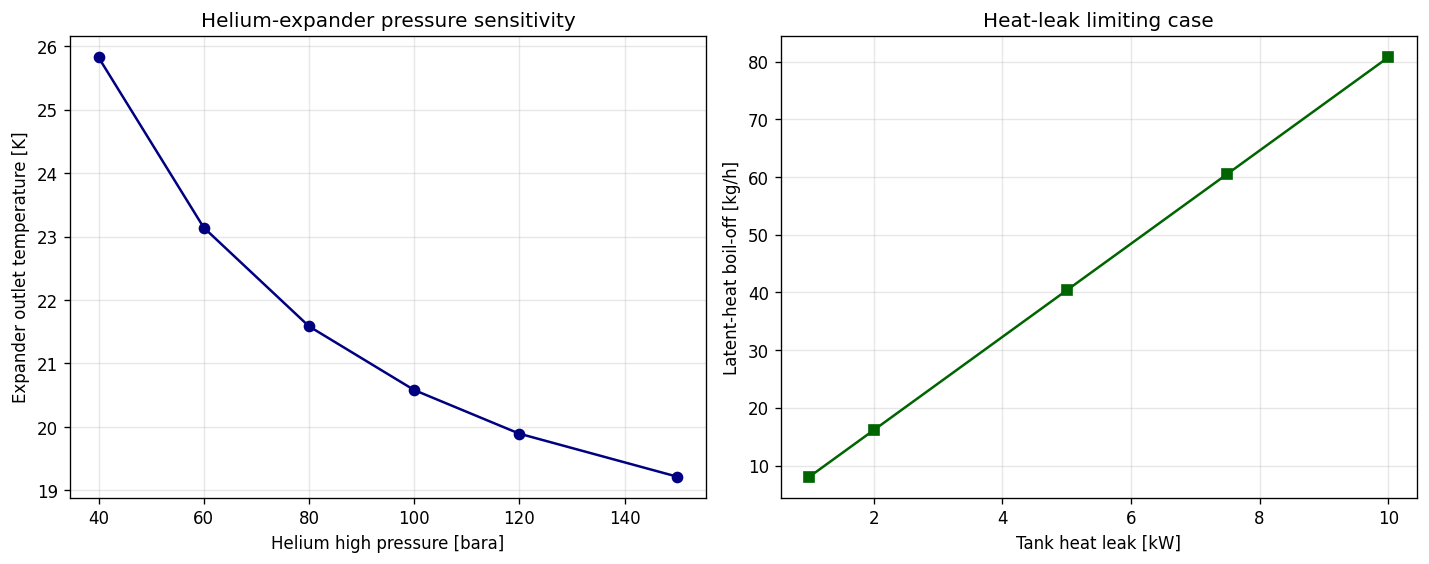

In [18]:
sensitivity_figure, sensitivity_axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

sensitivity_axes[0].plot(
    helium_sensitivity_table["high pressure [bara]"],
    helium_sensitivity_table["outlet temperature [K]"],
    color="navy",
    marker="o",
)
sensitivity_axes[0].set_xlabel("Helium high pressure [bara]")
sensitivity_axes[0].set_ylabel("Expander outlet temperature [K]")
sensitivity_axes[0].set_title("Helium-expander pressure sensitivity")
sensitivity_axes[0].grid(alpha=0.3)

sensitivity_axes[1].plot(
    boiloff_table["tank heat leak [kW]"],
    boiloff_table["boil-off [kg/h]"],
    color="darkgreen",
    marker="s",
)
sensitivity_axes[1].set_xlabel("Tank heat leak [kW]")
sensitivity_axes[1].set_ylabel("Latent-heat boil-off [kg/h]")
sensitivity_axes[1].set_title("Heat-leak limiting case")
sensitivity_axes[1].grid(alpha=0.3)

sensitivity_figure.tight_layout()
plt.show()


## 18. Practical limitations and troubleshooting

**Validity limits.** The SRK model does not distinguish normal, ortho-, and parahydrogen; is not a
quantum reference EOS; and omits solids, freeze-out impurities, catalytic conversion kinetics,
multistream exchanger pinch, recycle convergence, pressure drop, machinery maps, heat leak,
dynamics, metallurgy, relief, and hazardous-area design. The staged cooler and helium cycle are
educational screening models, not FEED or equipment guarantees.

**Troubleshooting.** Keep cryogenic temperature in kelvin. Check pressure against the critical
pressure before saturation calculations. Ensure both trial phases contain pure hydrogen before
reading fugacity coefficients. Build fresh streams and units in every sensitivity case. If a
phase-specific property is requested, inspect the phase type first. Validate cryogenic density,
latent heat, and saturation against a reference EOS before design use.

Hydrogen is highly flammable and has low ignition energy. Real systems require inert purging,
ventilation, leak detection, ignition control, pressure protection, and applicable codes and
standards; none is sized here.


In [19]:
verification_checks = {
    "composition closes": np.isclose(composition_sum, 1.0, atol=1.0e-12),
    "critical data are physical": 33.0 < critical_temperature_k < 33.4,
    "normal boiling benchmark passes": abs(boiling_point_error_k) < 1.0,
    "saturation rises with pressure": bool(
        np.all(np.diff(saturation_temperatures_k) > 0.0)
    ),
    "cooling enthalpy decreases": bool(np.all(enthalpy_differences < 0.0)),
    "feed is gas": state_table.iloc[0]["phase"] == "gas",
    "product is liquid": state_table.iloc[-1]["phase"] == "oil",
    "cooler duty closes": duty_relative_error < 1.0e-9,
    "mass closes": mass_relative_error < 1.0e-12,
    "latent-heat deviation is bounded": latent_heat_relative_error < 0.20,
    "minimum work is positive": minimum_work_kwh_per_kg > 0.0,
    "conversion heat exceeds latent heat": conversion_to_latent_ratio > 1.0,
    "helium reaches hydrogen cold end": (
        helium_cold_temperature_k
        < hydrogen_saturation_temperature(HYDROGEN_PRESSURE_BARA)
    ),
    "helium net shaft input is positive": helium_net_power_kw > 0.0,
    "density deviation is bounded": abs(density_relative_error) < 0.10,
    "boil-off rises with heat leak": bool(
        np.all(np.diff(boiloff_rates_kg_per_h) > 0.0)
    ),
}
failed_checks = [
    check_name
    for check_name, passed in verification_checks.items()
    if not passed
]

assert not failed_checks, failed_checks

print(f"Engineering checks passed [-]: {len(verification_checks)}")

for check_name in verification_checks:
    print(f"PASS - {check_name}")


Engineering checks passed [-]: 16
PASS - composition closes
PASS - critical data are physical
PASS - normal boiling benchmark passes
PASS - saturation rises with pressure
PASS - cooling enthalpy decreases
PASS - feed is gas
PASS - product is liquid
PASS - cooler duty closes
PASS - mass closes
PASS - latent-heat deviation is bounded
PASS - minimum work is positive
PASS - conversion heat exceeds latent heat
PASS - helium reaches hydrogen cold end
PASS - helium net shaft input is positive
PASS - density deviation is bounded
PASS - boil-off rises with heat leak


## 19. Summary, exercises, and authoritative references

NeqSim SRK predicts a 20.541 K normal boiling point, within 0.172 K of the 20.369 K reference,
but overpredicts liquid density and the 22-to-20 K condensation duty. The 1,000 kg/h hydrogen-side
cooler removes about 1.18 MW. The SRK flow-exergy calculation gives a reversible lower bound near
3.7 kWh/kg, while current liquefaction technology consumes more than 30% of hydrogen energy
content. A separately sourced ortho-to-para correction is larger than the latent heat and cannot
be ignored. The helium expander reaches the cold end, and storage calculations show why reference
density and heat-leak control matter.

**Further exercises.** (1) Replace SRK results with NIST REFPROP normal- and parahydrogen data.
(2) Add temperature-dependent para fraction and catalyst beds. (3) Construct composite curves and
enforce a minimum approach. (4) Close and converge the helium recycle. (5) Add nitrogen precooling
and compare total shaft work. (6) Couple a tank energy balance to pressure-dependent vent control.

**References.** Leachman et al., [NIST fundamental equations for para-, normal-, and
orthohydrogen](https://www.nist.gov/publications/fundamental-equations-state-parahydrogen-normal-hydrogen-and-orthohydrogen),
J. Phys. Chem. Ref. Data 38 (2009), DOI 10.1063/1.3160306; NIST
[fluid-property interface](https://webbook.nist.gov/chemistry/fluid/); U.S. DOE
[liquid hydrogen delivery](https://www.energy.gov/cmei/fuels/liquid-hydrogen-delivery) and
[hydrogen storage](https://www.energy.gov/cmei/fuels/hydrogen-storage); MagLab
[cryogenic hydrogen properties](https://maglabweb.magnet.fsu.edu/research/research-groups/cryogenics/educational-resources/);
and NeqSim [thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
and [process simulation](https://equinor.github.io/neqsim/process/process_simulation.html).


In [20]:
machine_readable_results = {
    "neqsim_version": NEQSIM_VERSION,
    "normal_boiling_temperature_k": srk_normal_boiling_k,
    "normal_boiling_error_k": boiling_point_error_k,
    "hydrogen_flow_kg_per_h": HYDROGEN_FLOW_KG_PER_H,
    "hydrogen_side_duty_kw": overall_duty_w / 1_000.0,
    "minimum_reversible_work_kwh_per_kg": minimum_work_kwh_per_kg,
    "ortho_para_heat_correction_kj_per_kg": ortho_para_heat_kj_per_kg,
    "liquid_density_kg_per_m3": liquid_hydrogen_density_kg_per_m3,
    "helium_expander_outlet_k": helium_cold_temperature_k,
    "checks_passed": len(verification_checks),
}

print(json.dumps(machine_readable_results, indent=2, sort_keys=True))


{
  "checks_passed": 16,
  "helium_expander_outlet_k": 20.581075958387416,
  "hydrogen_flow_kg_per_h": 1000.0,
  "hydrogen_side_duty_kw": 1182.6544232241517,
  "liquid_density_kg_per_m3": 75.48306966161074,
  "minimum_reversible_work_kwh_per_kg": 3.6924817282916935,
  "neqsim_version": "3.16.0",
  "normal_boiling_error_k": 0.17240829630202015,
  "normal_boiling_temperature_k": 20.54140829630202,
  "ortho_para_heat_correction_kj_per_kg": 525.844
}
